Ciclo Crisis 52-55 ignorado (fuera de rango)
Ciclo Expansión 56-69 ignorado (fuera de rango)
Ciclo Recesión 70-81 ignorado (fuera de rango)
Ciclo Crisis 82-84 ignorado (fuera de rango)


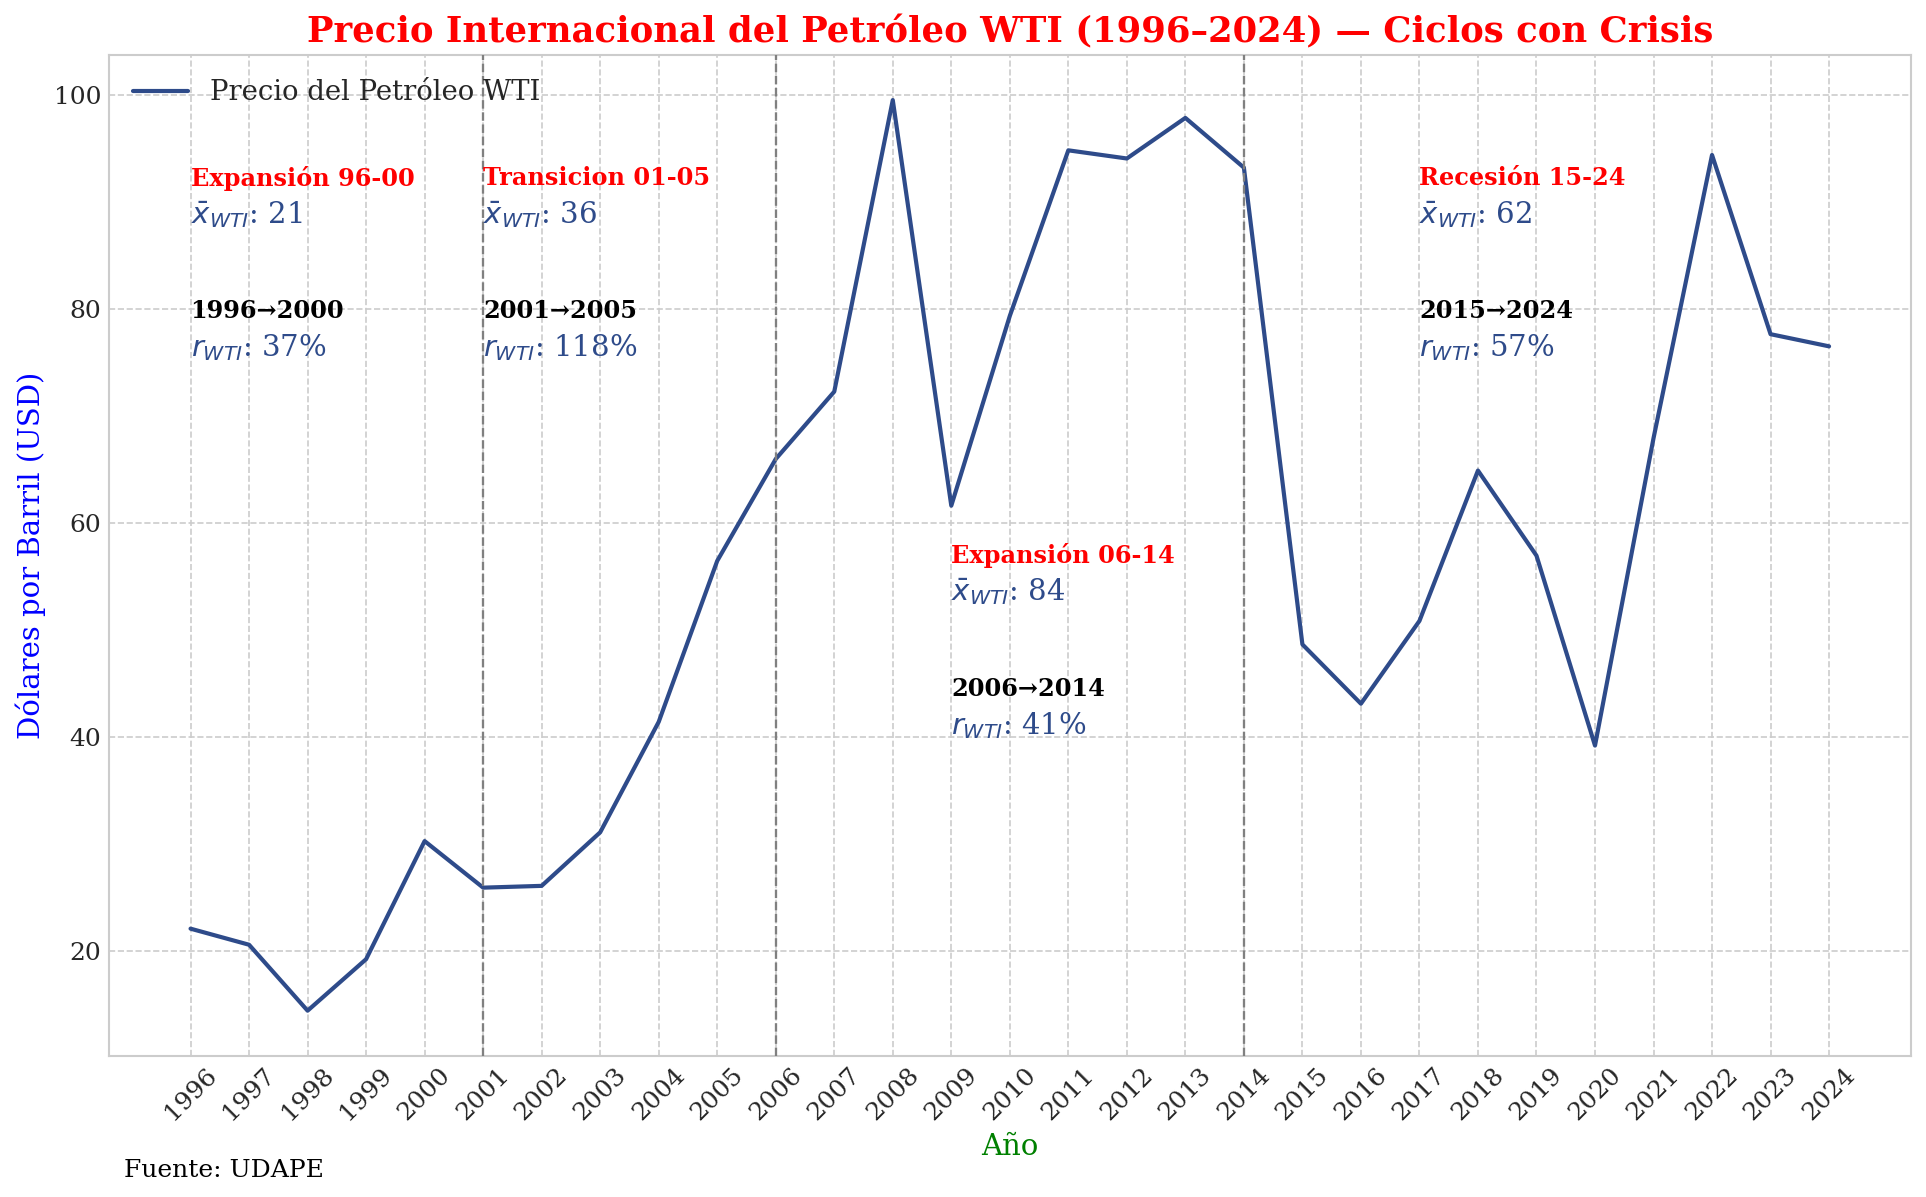

Gráfico guardado en: /home/navi/Desktop/archivos/DS/eco/Proyecto_macro/assets/tesis/serie_completa/precio_petroleo_wti/precio_petroleo_wti_ciclos.png


In [3]:
# ═══════════════════════════════════════════════════════════════════
# PRIMERA GRÁFICA: CICLOS CON CRISIS - LÍNEAS
# ═══════════════════════════════════════════════════════════════════

# ───────────────────────────── IMPORTS ──────────────────────────────
import os
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# IMPORTANTE: Importación correcta de las funciones auxiliares
from func_auxiliares.graficos_utils import (
    set_style,                          # Estilo corporativo
    init_base_plot,                     # Configuración base del gráfico
    add_hitos,                          # Líneas verticales de hitos
    add_cycle_means_multi,              # Medias por ciclo
    add_year_value_annotations,         # Anotaciones de valores por año
    add_period_growth_annotations_multi,# Tasas de crecimiento por período
    adjust_annot_years,                 # Ajustar años de anotación al DataFrame
    adjust_cycles,                      # Ajustar ciclos al DataFrame
    adjust_periods,                     # Ajustar períodos al DataFrame
    get_df                              # Función helper para cargar datos
)

from func_auxiliares.config import (
    DB_PATH,                            # Ruta a la base de datos
    CYCLES,                             # Diccionario de ciclos económicos
    ASSETS_DIR,                         # Directorio de assets
    annot_years,                        # Lista de años para anotaciones
    periodos_tasas,                     # Períodos para calcular tasas
    hitos_v,                            # Diccionario de hitos verticales
)

# ─────────────────────── 1. CONFIGURACIÓN GENERAL ───────────────────
output_dir = ASSETS_DIR / "serie_completa" / "precio_petroleo_wti"
os.makedirs(output_dir, exist_ok=True)
set_style()  # Aplica el estilo corporativo unificado

# ───────────────────────── 2. CARGA DE DATOS ────────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = (
        pd.read_sql(
            "SELECT * FROM precio_petroleo_wti",
            conn,
            index_col="año"
        )
        .sort_index()
    )

# ──────────────── 3. COMPONENTES Y PREPARACIÓN ──────────────────────
# Definir las series a graficar (tuplas de columna_df, etiqueta_display)
componentes = [
    ("precio", "Precio del Petróleo WTI"),
]

# Extraer solo los nombres de columnas
cols_componentes = [col for col, _ in componentes]

# Definir colores para cada serie
colors = {
    "precio": "#2E4B8A",  # Azul petróleo
}

# Abreviaciones para anotaciones (texto más corto)
abbr_map = {
    "precio": "WTI",
}

# ──────────────── 4. PREPARACIÓN DE CICLOS Y PERÍODOS ────────────────
# Ajustar configuraciones globales al DataFrame actual
annotate_years = adjust_annot_years(df, annot_years)
cycles = adjust_cycles(df, CYCLES)
periods = adjust_periods(df, periodos_tasas)

# Calcular estadísticas por ciclo (medias)
cycle_stats = {
    name: df.loc[period, cols_componentes].mean().to_dict()
    for name, period in cycles.items()
}

# ───────────── 5. OFFSETS Y UTILIDADES (POSICIONAMIENTO) ────────────

# A) Offsets para anotaciones de valores por año y serie
annotation_offsets = {
    # "precio": {
    #     1996: (0, 3),       # (desplazamiento_x, desplazamiento_y)
    #     2001: (0, 5),       # Crisis del dot-com
    #     2006: (-1.5, 8),    # Inicio del boom de commodities
    #     2008: (0, -8),      # Crisis financiera global
    #     2014: (-2.5, -8),   # Caída de precios de petróleo
    #     2020: (0, -12),     # Pandemia COVID-19
    #     2022: (0, 8),       # Post-pandemia/Guerra Ucrania
    # },
}

# B) Offsets para líneas verticales de hitos
hitos_offset = {year: 0.8 for year in hitos_v}  # Altura relativa uniforme

# C) Offsets para medias por ciclo
medias_offsets = {
    "Expansión 96-00": (1996, 0.90),
    "Transicion 01-05": (2001, 0.90),
    "Expansión 06-14": (2009, 0.56),
    "Recesión 15-24": (2017, 0.90),
}
# D) Offsets para tasas de crecimiento por período
tasas_offsets = {
    "1996-2000": (1996, 0.78),
    "2001-2005": (2001, 0.78),
    "2006-2014": (2009, 0.44),
    "2015-2024": (2017, 0.78)
}

# ────────────────────────── 6. GRÁFICO BASE ──────────────────────────
fig, ax = init_base_plot(
    df=df,
    series=componentes,           # Lista de tuplas (columna, etiqueta)
    colors=colors,                # Diccionario de colores
    title=f"Precio Internacional del Petróleo WTI ({df.index.min()}–{df.index.max()}) — Ciclos con Crisis",
    xlabel="Año",
    ylabel="Dólares por Barril (USD)",
    source_text="Fuente: UDAPE"
)

# ────────────────────── 7. ELEMENTOS GRÁFICOS ADICIONALES ────────────

# A) Líneas verticales de hitos históricos
add_hitos(ax, df.index, hitos_v, hitos_offset)

# B) Anotaciones de valores en años específicos
add_year_value_annotations(
    ax, df, annotate_years,
    cols_componentes, annotation_offsets, colors,
    arrow_lw=0.4,                # Grosor de flecha
)

# C) Medias por ciclo económico
y_max = ax.get_ylim()[1]
line_spacing = y_max * 0.03
add_cycle_means_multi(
    ax,
    cycle_stats,
    medias_offsets,
    abbr_map,
    colors,
    line_spacing=line_spacing    # Espaciado entre líneas
)

# D) Tasas de crecimiento por período
add_period_growth_annotations_multi(
    ax, df, periods,
    cols_componentes,
    tasas_offsets,
    colors,
    abbr_map, 
)

# ────────────────────────── 8. FINALIZACIÓN ──────────────────────────
plt.tight_layout()

# Guardar en formato PNG de alta resolución
filename_base = f"{output_dir}/precio_petroleo_wti_ciclos"
fig.savefig(f"{filename_base}.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()  # IMPORTANTE: Cerrar la figura para liberar memoria

print(f"Gráfico guardado en: {filename_base}.png")